# 3장 2강: 피어슨 상관계수의 의미와 한계 — 실습문제

## 실습 목표

- 두 연속형 변수의 피어슨 상관계수와 p-value를 계산하고 방향·강도를 해석합니다.
- 결정계수 $r^2$의 의미를 올바르게 설명합니다.
- 산점도를 함께 확인하여 이상치와 비선형 관계가 피어슨 상관계수에 미치는 영향을 판단합니다.
- 상관관계만으로 인과관계를 주장할 수 없는 이유와 가능한 혼란변수를 설명합니다.

## 실습 환경 / 데이터

- Python, pandas, NumPy, SciPy, Matplotlib
- `ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `LotArea`
- 모든 판단은 유의수준 $\alpha=0.05$를 기준으로 합니다.

## 실습 준비

아래 셀을 실행해 데이터를 불러오고 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
if "Malgun Gothic" in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
from scipy import stats

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("data/ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더 또는 data 폴더에 넣어주세요.")

df = pd.read_csv(data_path)
alpha = 0.05

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적과 매매가격의 피어슨 상관분석

`GrLivArea`와 `SalePrice`의 선형 관계를 분석하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. `stats.pearsonr()`로 피어슨 상관계수 $r$과 p-value를 계산하세요.
3. $r^2$을 계산하세요.
4. 축 이름과 제목이 있는 산점도를 그리세요.
5. 아래 질문에 문장으로 답하세요.

### 질문

- 상관관계의 방향과 강도는 어떠한가요?
- p-value를 기준으로 선형 상관관계가 통계적으로 유의한가요?
- $r^2$은 이 관계에서 무엇을 의미하나요?
- 이 결과만으로 생활면적 증가가 매매가격 상승의 원인이라고 말할 수 있나요?


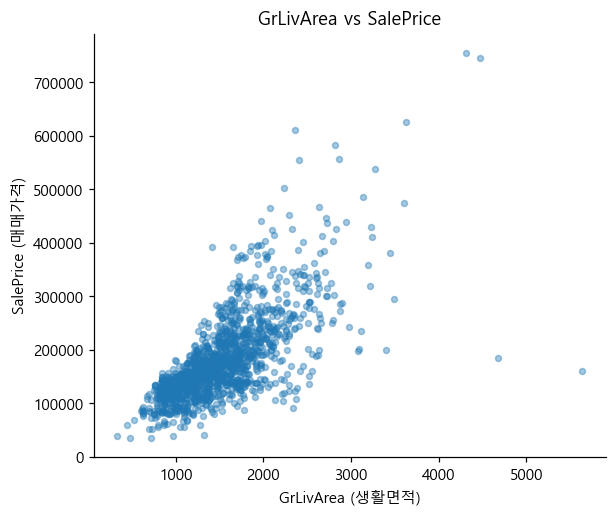

n = 1460
r = 0.7086
p-value = 4.518e-223
r^2 = 0.5021


In [2]:
# 1. GrLivArea, SalePrice 결측치 제거한 분석용 데이터 생성
df_q1 = df[['GrLivArea', 'SalePrice']].dropna()

# 2. 피어슨 상관계수와 p-value 계산
r_q1, p_q1 = stats.pearsonr(df_q1['GrLivArea'], df_q1['SalePrice'])

# 3. r^2 계산
r2_q1 = r_q1 ** 2

# 4. 산점도
plt.figure(figsize=(6, 5))
plt.scatter(df_q1['GrLivArea'], df_q1['SalePrice'], alpha=0.4, s=15)
plt.xlabel('GrLivArea (생활면적)')
plt.ylabel('SalePrice (매매가격)')
plt.title('GrLivArea vs SalePrice')
plt.show()

# 5. 결과 출력
print(f"n = {len(df_q1)}")
print(f"r = {r_q1:.4f}")
print(f"p-value = {p_q1:.4g}")
print(f"r^2 = {r2_q1:.4f}")


### 필수 1 답변

- **방향과 강도:** r=0.7086로 비교적 강한 양의 선형 관계입니다. 강도 구분은 분야에 따른 해석 기준이지 절대적 경계는 아닙니다.
- **통계적 유의성:** p=4.518e-223<0.05이므로 모집단의 피어슨 상관계수 0이라는 귀무가설을 기각합니다.
- **결정계수:** r²=0.5021는 절편을 포함한 단순선형회귀에서 표본 가격 변동의 약 50.21%가 생활면적과의 선형 관계로 설명됨을 의미합니다. 나머지는 이 모델이 설명하지 못하는 변동이며 다른 요인, 비선형성, 잡음 등이 포함될 수 있습니다.
- **인과관계:** 면적 증가가 가격 상승을 일으킨다는 결론은 낼 수 없습니다. 위치·품질·건축연도 등 혼란변수와 자료 수집 구조를 고려해야 합니다.


---

## 필수 2. 피어슨 상관계수의 두 가지 한계 확인

피어슨 상관계수가 이상치에 민감하고 비선형 관계를 놓칠 수 있다는 점을 확인하세요.

### A. 이상치의 영향

1. `GrLivArea`, `SalePrice`에서 `random_state=42`로 50행을 표본 추출하세요.
2. 표본의 $r$과 p-value를 계산하세요.
3. 학습용 가상 이상치 `(GrLivArea=6000, SalePrice=50000)` 한 행을 표본에만 추가하세요. 원본 `df`는 변경하지 마세요.
4. 이상치 추가 후 $r$과 p-value를 다시 계산하세요.
5. 추가 전후 산점도를 나란히 그리고 결과를 비교하세요.

### B. 비선형 관계

1. `x = [-3, -2, -1, 0, 1, 2, 3]`, `y = x**2`를 만드세요.
2. $x$와 $y$의 $r$과 p-value를 계산하고 산점도를 그리세요.

### 질문

- 이상치 추가 전후 $r$과 유의성 판단은 어떻게 달라졌나요?
- 이 결과는 왜 산점도를 함께 확인해야 함을 보여주나요?
- $y=x^2$는 분명한 관계인데도 $r$이 0에 가까운 이유는 무엇인가요?
- `r ≈ 0`을 “두 변수 사이에 아무 관계도 없다”로 해석해도 되나요?


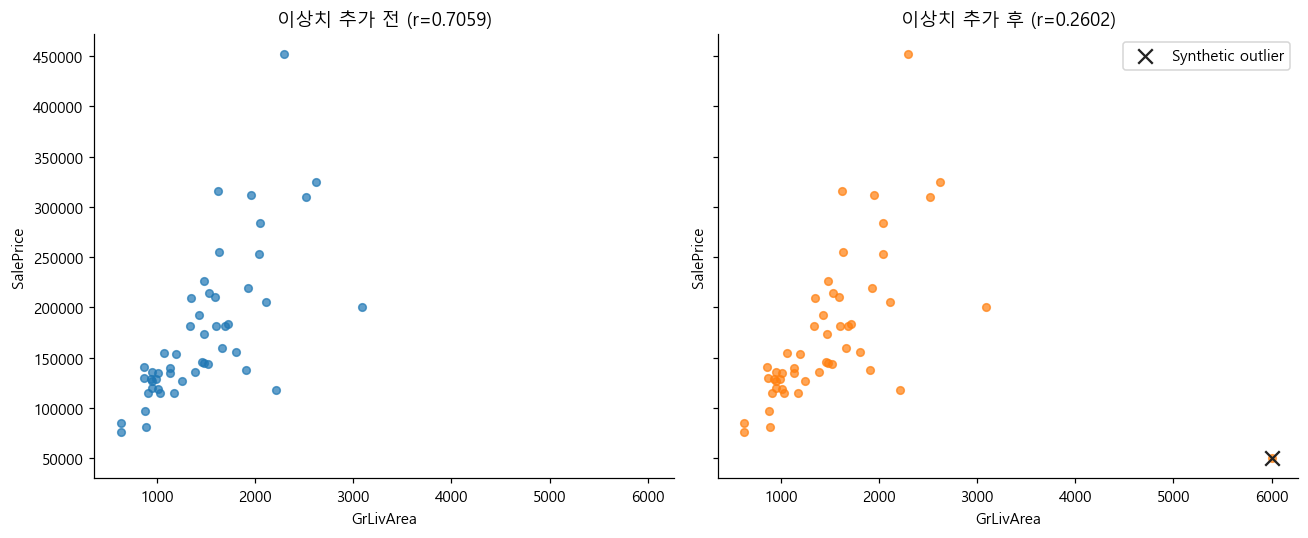

=== A. 이상치의 영향 ===
이상치 추가 전: n=50, r=0.7059, p-value=1.026e-08
이상치 추가 후: n=51, r=0.2602, p-value=0.06514


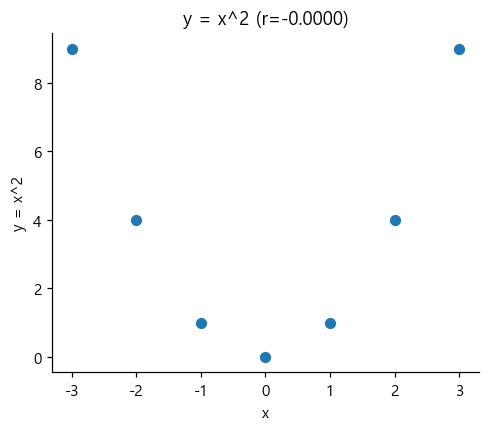


=== B. 비선형 관계 (y = x^2) ===
r = -0.0000
p-value = 1


In [3]:
# A. 이상치의 영향
# 1. GrLivArea, SalePrice에서 random_state=42로 50행 표본 추출
sample_df = df[['GrLivArea', 'SalePrice']].dropna().sample(n=50, random_state=42).reset_index(drop=True)

# 2. 표본의 r, p-value 계산 (이상치 추가 전)
r_before, p_before = stats.pearsonr(sample_df['GrLivArea'], sample_df['SalePrice'])

# 3. 표본을 복사한 새 데이터프레임에 가상 이상치 행 추가 (원본 df, sample_df는 변경하지 않음)
sample_with_outlier = sample_df.copy()
outlier_row = pd.DataFrame({'GrLivArea': [6000], 'SalePrice': [50000]})
sample_with_outlier = pd.concat([sample_with_outlier, outlier_row], ignore_index=True)

# 4. 이상치 추가 후 r, p-value 재계산
r_after, p_after = stats.pearsonr(sample_with_outlier['GrLivArea'], sample_with_outlier['SalePrice'])

# 5. 추가 전/후 산점도를 나란히 그리기
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
axes[0].scatter(sample_df['GrLivArea'], sample_df['SalePrice'], alpha=0.7, s=25)
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')
axes[0].set_title(f'이상치 추가 전 (r={r_before:.4f})')

axes[1].scatter(sample_with_outlier['GrLivArea'], sample_with_outlier['SalePrice'], alpha=0.7, s=25, color='tab:orange')
axes[1].set_xlabel('GrLivArea')
axes[1].set_ylabel('SalePrice')
axes[1].set_title(f'이상치 추가 후 (r={r_after:.4f})')
axes[1].scatter([6000], [50000], marker='x', s=90, color='#222222', label='Synthetic outlier')
axes[1].legend()
plt.tight_layout()
plt.show()

print('=== A. 이상치의 영향 ===')
print(f'이상치 추가 전: n={len(sample_df)}, r={r_before:.4f}, p-value={p_before:.4g}')
print(f'이상치 추가 후: n={len(sample_with_outlier)}, r={r_after:.4f}, p-value={p_after:.4g}')

# B. 비선형 관계
x = np.array([-3, -2, -1, 0, 1, 2, 3])
y = x ** 2

r_nonlinear, p_nonlinear = stats.pearsonr(x, y)

plt.figure(figsize=(5, 4))
plt.scatter(x, y, s=40)
plt.xlabel('x')
plt.ylabel('y = x^2')
plt.title(f'y = x^2 (r={r_nonlinear:.4f})')
plt.show()

print()
print('=== B. 비선형 관계 (y = x^2) ===')
print(f'r = {r_nonlinear:.4f}')
print(f'p-value = {p_nonlinear:.4g}')


### 필수 2 답변

- **이상치 전후:** 추가 전 r=0.7059, p=1.026e-08; 추가 후 r=0.2602, p=0.06514입니다. 상관은 약해지고, 0.05 기준에서 유의했던 결과가 유의하지 않게 바뀝니다.
- **산점도의 역할:** 원본 50개 관측치의 경향과 반대 방향에 있는 가상 극단점 하나가 상관계수를 크게 바꾸는 모습을 확인할 수 있습니다. 이상치는 오류 여부와 맥락을 확인해야 하며 유의성을 높이기 위해 임의로 삭제하면 안 됩니다.
- **비선형 예제:** 대칭인 x와 y=x²에서 양·음 방향의 공분산 기여가 상쇄되어 r≈0, p≈1입니다. 이 배열은 결정적으로 만든 교육용 예제이므로 p값을 실제 모집단 추론으로 확대하지 않습니다.
- **r≈0 해석:** 선형 관계가 약하다는 의미이지 모든 관계가 없거나 두 변수가 독립이라는 뜻은 아닙니다.

---

## 과제. 대지면적과 매매가격의 관계를 근거 있게 보고하기

`LotArea`와 `SalePrice`의 관계를 분석하고, 상관과 인과를 구별한 짧은 분석 보고를 작성하세요.

### 수행 요구사항

1. 두 변수의 피어슨 상관계수, p-value, $r^2$을 계산하세요.
2. 산점도를 그려 관계의 형태와 이상치 여부를 확인하세요.
3. 유의수준 0.05에서 통계적 유의성을 판단하세요.
4. 아래 질문에 빠짐없이 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 관계의 방향과 강도는 어떠한가요?
- 통계적으로 유의한 결과와 강한 관계는 같은 의미인가요?
- 대지면적이 넓어지면 매매가격이 오른다는 인과결론을 내릴 수 있나요?
- 두 변수에 함께 영향을 줄 수 있는 혼란변수를 두 가지 이상 제시하세요.
- 피어슨 상관계수가 0에 가까우면 두 변수 사이에 아무 관계도 없다고 판단해도 되나요? U자형 관계를 예로 들어 설명하세요.

n=1460, r=0.263843, p=1.12314e-24, r²=0.069613
선형 상관 유의


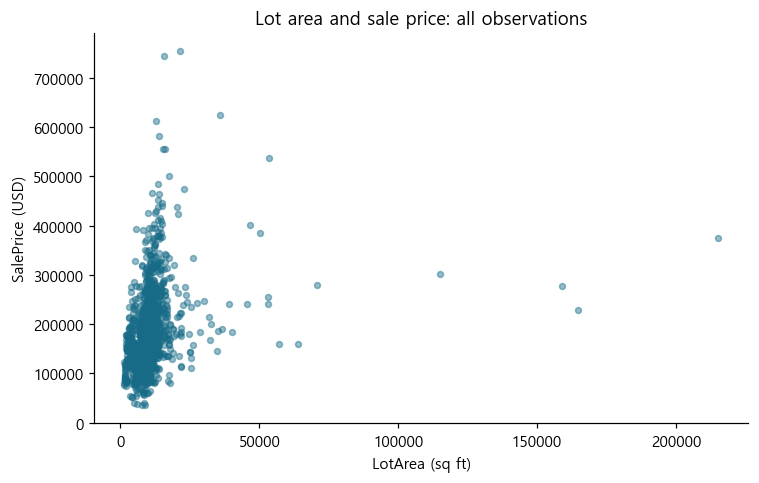

In [4]:
lot_data = df[["LotArea", "SalePrice"]].dropna()
r_lot, p_lot = stats.pearsonr(lot_data.LotArea, lot_data.SalePrice)
print(f"n={len(lot_data)}, r={r_lot:.6f}, p={p_lot:.6g}, r²={r_lot**2:.6f}")
print("선형 상관 유의" if p_lot < alpha else "선형 상관의 증거 부족")
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(lot_data.LotArea, lot_data.SalePrice, s=15, alpha=0.45, color="#176B87")
ax.set(xlabel="LotArea (sq ft)", ylabel="SalePrice (USD)", title="Lot area and sale price: all observations")
fig.tight_layout()
plt.show()


### 과제 결론

대지면적과 매매가격은 \(r=0.2638\)로 약한 양의 선형 관계를 보입니다.
\(p=1.123\times10^{-24}\)로 통계적으로 유의하지만, \(r^2=0.0696\)으로 표본 가격 변동의 약 6.96%만 단순 선형 관계로 설명되므로 통계적으로 유의하다는 것과 관계가 강하다는 것은 같은 의미가 아닙니다.
산점도에는 대부분의 주택이 작은 대지면적 구간에 몰려 있고 일부 매우 넓은 대지 관측치가 있으므로 극단값이 상관계수에 미치는 영향에도 주의해야 합니다.
또한 피어슨 상관계수가 0에 가깝더라도 아무 관계가 없다고 판단할 수는 없으며, 예를 들어 \(y=x^2\)와 같은 U자형 관계에서는 두 변수 사이에 명확한 비선형 관계가 존재해도 양쪽 방향의 선형 경향이 상쇄되어 \(r\)이 0에 가까워질 수 있습니다.
관측 자료에서 확인된 상관관계만으로 대지면적을 넓히면 매매가격이 상승한다는 인과관계를 결론 내릴 수 없습니다.
동네 위치(Neighborhood), 전체 품질(OverallQual), 생활면적(GrLivArea) 등이 대지면적과 매매가격에 함께 영향을 줄 수 있으므로 이러한 혼란변수를 고려한 추가 분석이 필요합니다.


---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

피어슨 상관계수의 숫자만 보았을 때 놓칠 수 있었던 점, 산점도와 인과적 관점을 추가해 해석이 어떻게 개선되었는지 정리하세요.

### 마무리 답변

1. 상관계수 한 개만 보면 극단값의 영향과 비선형성을 놓치고 유의성을 관계 강도 또는 인과관계로 오해할 수 있었습니다.

2. 동일한 표본의 이상치 추가 전후를 비교하고, U자형 예제와 전체 산점도를 함께 확인했으며 가능한 혼란변수를 명시했습니다.

3. 가상 이상치 한 개로 r이 0.7059에서 0.2602로 변했고, y=x² 예제는 관계가 명확해도 r≈0입니다. LotArea는 p<0.05지만 r²=0.0696에 그쳐 통계적 유의성과 설명력을 구분할 근거가 됩니다.
